**Introduction **

The purpose of this stage is to transform the raw CFD dataset exported from OpenFOAM into a structured and machine learning-ready format. Although the dataset accurately represents the physical flow field, it contains additional dimensions and naming conventions that are not suitable for direct use in machine learning models. Therefore, this stage focuses on removing unnecessary variables, renaming features for clarity, validating the cleaned dataset, and preparing the data for subsequent normalization and model development. The final objective is to obtain a two-dimensional dataset that maps spatial coordinates to flow variables in a consistent and interpretable format.

In [4]:
import pandas as pd

df = pd.read_excel("/content/CFD  - 2D flow.xlsx")

df.head()

,Points:0,Points:1,Points:2,U:0,U:1,U:2,p
0,0.000500,0.0,-0.0005,0.000000e+00,0.000000e+00,0.000000e+00,-0.00062
1,0.000500,0.0,-0.0005,2.542700e-10,1.285000e-07,0.000000e+00,-0.00062
2,0.000501,0.0,-0.0005,3.686500e-10,1.859700e-07,0.000000e+00,-0.00062
3,0.000501,0.0,-0.0005,7.044800e-10,2.305500e-07,-5.079300e-29,-0.00062
4,0.000502,0.0,-0.0005,1.129000e-09,2.857700e-07,2.947200e-26,-0.00062


In [5]:
print(df.columns)
print(df.shape)

Index(['Points:0', 'Points:1', 'Points:2', 'U:0', 'U:1', 'U:2', 'p'], dtype='object')
(15254, 7)


In [6]:
## RENAME COLUMNS
df_clean = df.rename(columns={
    "Points:0": "x",
    "Points:1": "y",
    "Points:2": "z",
    "U:0": "u",
    "U:1": "v",
    "U:2": "w",
    "p": "p"
})

df_clean.head()

,x,y,z,u,v,w,p
0,0.000500,0.0,-0.0005,0.000000e+00,0.000000e+00,0.000000e+00,-0.00062
1,0.000500,0.0,-0.0005,2.542700e-10,1.285000e-07,0.000000e+00,-0.00062
2,0.000501,0.0,-0.0005,3.686500e-10,1.859700e-07,0.000000e+00,-0.00062
3,0.000501,0.0,-0.0005,7.044800e-10,2.305500e-07,-5.079300e-29,-0.00062
4,0.000502,0.0,-0.0005,1.129000e-09,2.857700e-07,2.947200e-26,-0.00062


In [7]:
## REMOVE UNNECESSARY DIMENSIONS
df_clean = df_clean[["x", "y", "u", "v", "p"]]

df_clean.head()

,x,y,u,v,p
0,0.000500,0.0,0.000000e+00,0.000000e+00,-0.00062
1,0.000500,0.0,2.542700e-10,1.285000e-07,-0.00062
2,0.000501,0.0,3.686500e-10,1.859700e-07,-0.00062
3,0.000501,0.0,7.044800e-10,2.305500e-07,-0.00062
4,0.000502,0.0,1.129000e-09,2.857700e-07,-0.00062


In [8]:
## VERIFY CLEANED DATASET
print("Columns after cleaning:", df_clean.columns)
print("Shape after cleaning:", df_clean.shape)

Columns after cleaning: Index(['x', 'y', 'u', 'v', 'p'], dtype='object')
Shape after cleaning: (15254, 5)


In [9]:
## CHECK AGAIN FOR SAFETY
print(df_clean.isnull().sum())

x    0
y    0
u    0
v    0
p    0
dtype: int64


In [10]:
## BASIC CHECK AFTER CLEANING
df_clean.describe()

,x,y,u,v,p
count,15254.000000,1.525400e+04,1.525400e+04,1.525400e+04,15254.000000
mean,0.010062,6.246042e-03,4.454733e-03,-2.573395e-05,0.000024
std,0.022813,1.423900e-02,5.415735e-03,7.590892e-04,0.000591
min,-0.100000,-5.989100e-18,-3.291500e-05,-2.287700e-02,-0.002441
25%,-0.000150,3.576000e-04,-5.930150e-10,-1.041725e-05,-0.000309
50%,0.000545,8.045200e-04,2.180800e-03,1.182300e-09,0.000077
75%,0.011601,5.459300e-03,7.156425e-03,9.136025e-06,0.000250
max,0.100000,1.000000e-01,1.834100e-02,1.883200e-03,0.002610


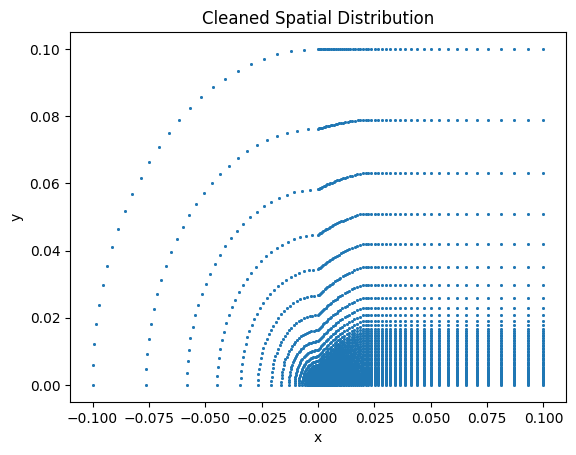

In [11]:
## VISUAL CONFIRMATION
import matplotlib.pyplot as plt

plt.scatter(df_clean["x"], df_clean["y"], s=1)
plt.title("Cleaned Spatial Distribution")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [12]:
## SAVE CLEANED DATASET
df_clean.to_csv("CFD_2D_cleaned.csv", index=False)

**CONCLUSION **

The data cleaning process was successfully completed by restructuring the dataset into a two-dimensional format suitable for machine learning applications. The original OpenFOAM dataset contained additional spatial and velocity components corresponding to the z-direction, which were removed as they do not contribute to the two-dimensional flow representation. The remaining variables, consisting of spatial coordinates (x, y) and flow variables (u, v, p), were retained and renamed for clarity and consistency. The cleaned dataset was verified to be complete, free of missing values, and physically consistent with the simulation results. This processed dataset now provides a suitable foundation for normalization and subsequent model development, including both physics-informed and data-driven approaches.